## Cell 1 — Imports and config

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point

CRIME_CSV        = r'E:\Documents\Claude\Projects\Data Encoding\london_crime_2025.csv'
CRS_METRIC       = 'EPSG:27700'
GRID_M           = 200

SEVERITY_ORDER   = ['Low', 'Medium', 'High']
SEVERITY_COLORS  = {'Low': "#F1ED6C", 'Medium': '#FF9800', 'High': '#F44336'}
SEVERITY_WEIGHTS = {'Low': 1, 'Medium': 2, 'High': 3}

## Cell 2 — Load crime data

In [5]:
crimes = pd.read_csv(CRIME_CSV)
print(f'Total rows: {len(crimes):,}')

# Drop unclassified rows (NaN severity)
crimes = crimes.dropna(subset=['severity_class'])
print(f'Classified rows: {len(crimes):,}')
print()
print(crimes['severity_class'].value_counts())

# Convert to GeoDataFrame and reproject
geometry   = gpd.points_from_xy(crimes['longitude'], crimes['latitude'])
crimes_gdf = gpd.GeoDataFrame(crimes, geometry=geometry, crs='EPSG:4326')
crimes_m   = crimes_gdf.to_crs(CRS_METRIC).copy()
crimes_m['x']      = crimes_m.geometry.x
crimes_m['y']      = crimes_m.geometry.y
crimes_m['weight'] = crimes_m['severity_class'].map(SEVERITY_WEIGHTS)

print(f'\nReprojected to {CRS_METRIC} — ready for plotting.')

Total rows: 1,140,416
Classified rows: 984,760

severity_class
Low       521231
High      301447
Medium    162082
Name: count, dtype: int64

Reprojected to EPSG:27700 — ready for plotting.


## Cell 3 — Severity breakdown

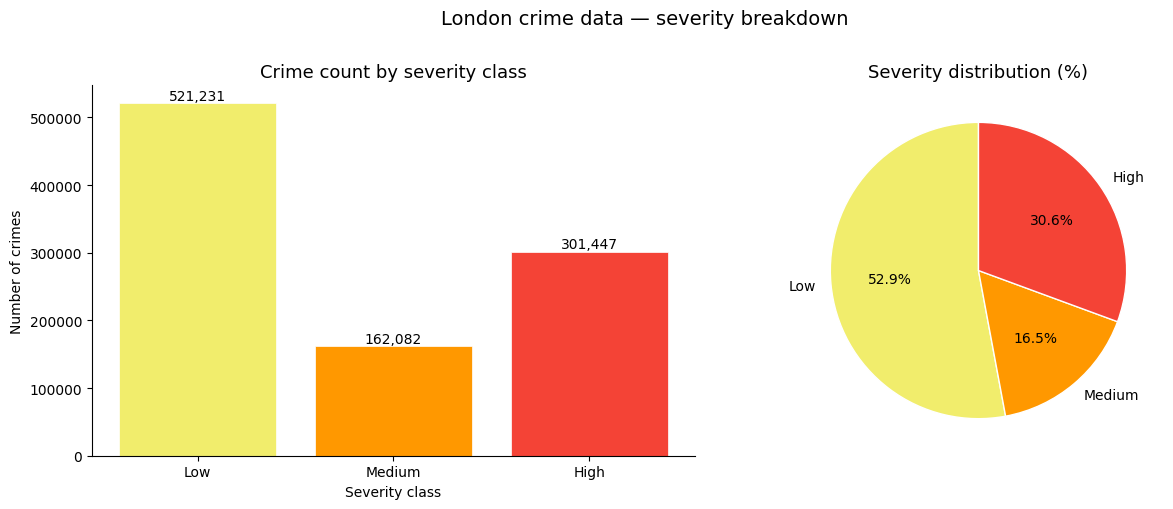

In [7]:
counts = crimes_m['severity_class'].value_counts().reindex(SEVERITY_ORDER)
colors  = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(SEVERITY_ORDER, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Crime count by severity class', fontsize=13)
axes[0].set_xlabel('Severity class')
axes[0].set_ylabel('Number of crimes')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=SEVERITY_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1)
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title('Severity distribution (%)', fontsize=13)

plt.suptitle('London crime data — severity breakdown', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 4 — Spatial plots
#### Hexbin density per severity class (Low / Medium / High). Each hexagon shows how many crimes of that class fell inside it.

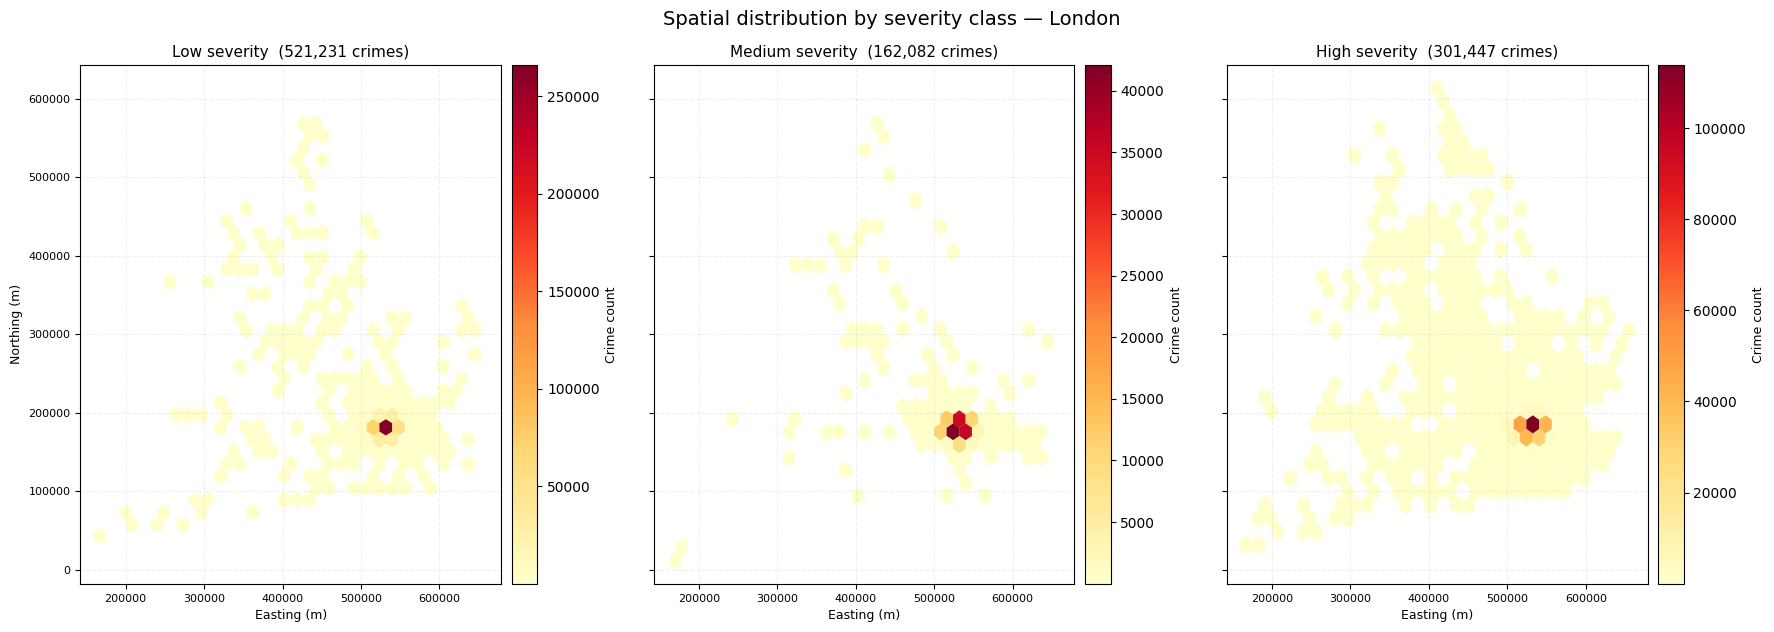

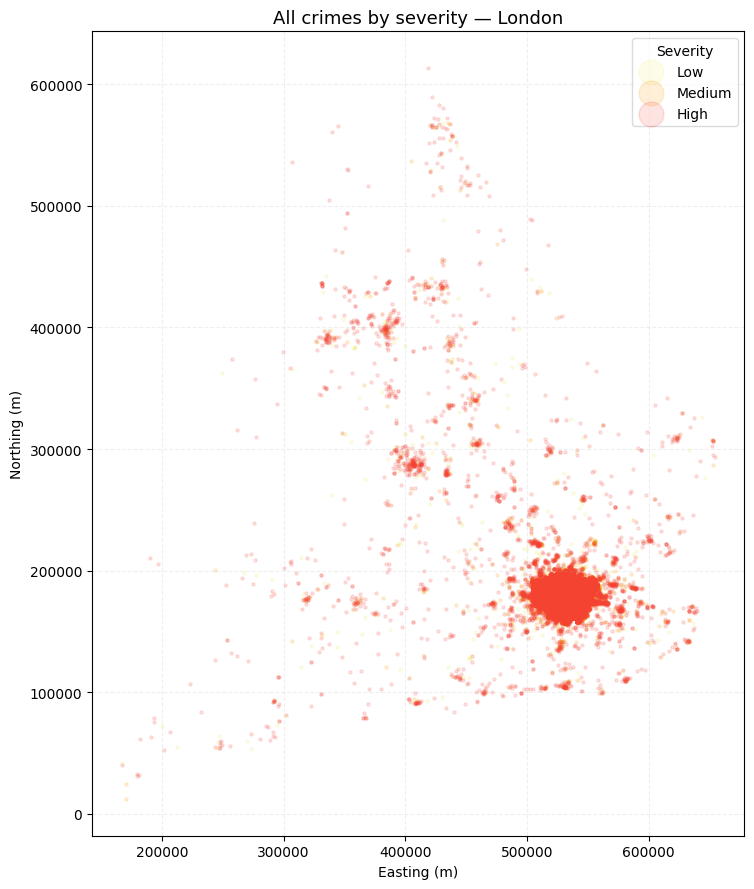

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, sev in zip(axes, SEVERITY_ORDER):
    sub = crimes_m[crimes_m['severity_class'] == sev]
    hb  = ax.hexbin(sub['x'], sub['y'], gridsize=30, cmap='YlOrRd', mincnt=1, linewidths=0.1)
    cb  = plt.colorbar(hb, ax=ax, pad=0.02)
    cb.set_label('Crime count', fontsize=9)
    ax.set_title(f'{sev} severity  ({len(sub):,} crimes)', fontsize=11)
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Northing (m)', fontsize=9)
plt.suptitle('Spatial distribution by severity class — London', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# All classes overlaid on one map
fig2, ax2 = plt.subplots(figsize=(9, 9))
for sev in SEVERITY_ORDER:
    sub = crimes_m[crimes_m['severity_class'] == sev]
    ax2.scatter(sub['x'], sub['y'], s=5, alpha=0.15, color=SEVERITY_COLORS[sev],
                label=sev, rasterized=True)
ax2.set_title('All crimes by severity — London', fontsize=13)
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.legend(markerscale=8, title='Severity', framealpha=0.7)
plt.tight_layout()
plt.show()

## Cell 4b — Single hexgrid colored by total crime density
#### All crimes combined into one hexbin, with color intensity representing the total crime count per cell.


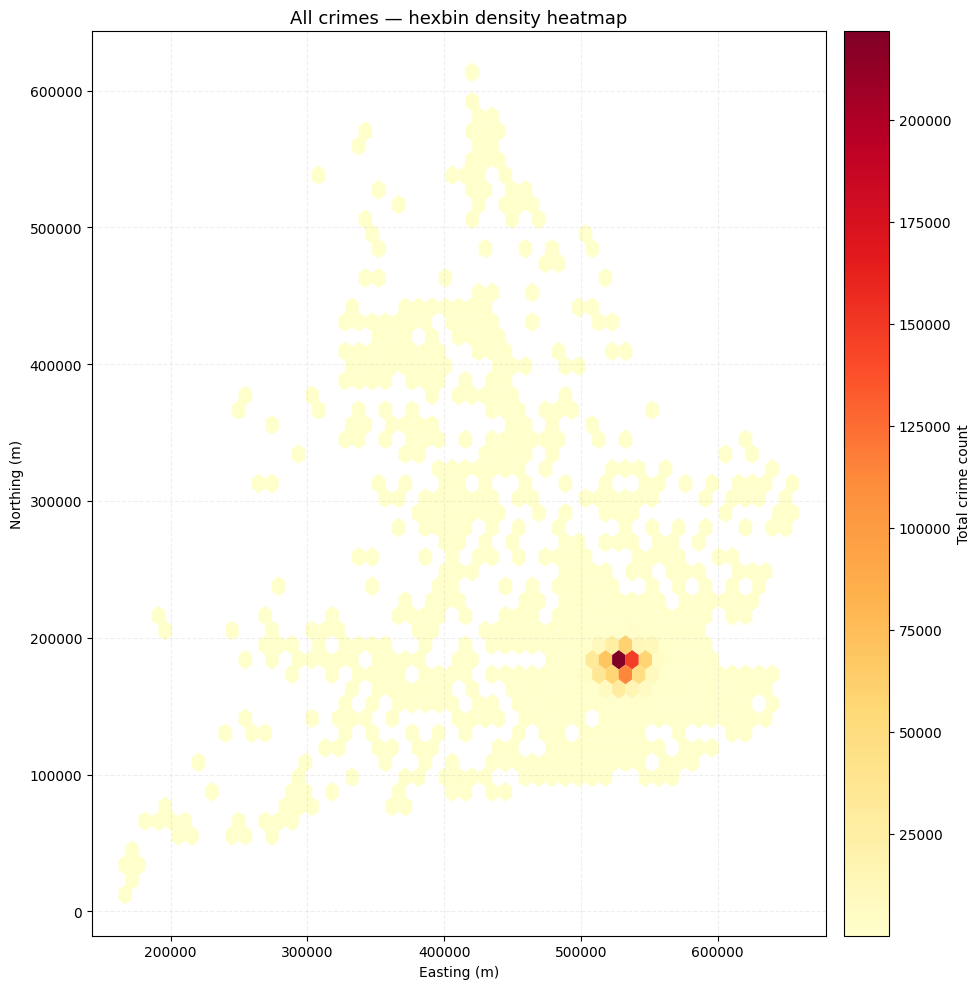

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

# Single hexbin with all crimes, colored by count
hb = ax.hexbin(crimes_m['x'], crimes_m['y'], gridsize=50, cmap='YlOrRd', mincnt=1, linewidths=0.1)
cb = plt.colorbar(hb, ax=ax, pad=0.02)
cb.set_label('Total crime count', fontsize=10)

ax.set_title('All crimes — hexbin density heatmap', fontsize=13)
ax.set_xlabel('Easting (m)', fontsize=10)
ax.set_ylabel('Northing (m)', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

## Cell 4c — Weighted score definition

The **weighted score** is a severity-adjusted crime metric:
- **Low severity** → weight = 1
- **Medium severity** → weight = 2  
- **High severity** → weight = 3

For each grid cell, the weighted score is the **sum of weights** of all crimes in that cell. This emphasizes high-severity crimes and provides a more nuanced measure of crime burden than raw count alone.

Example: A cell with 2 Low + 1 Medium crime has a raw count of **3** but a weighted score of **2(1) + 1(2) = 4**.


## Cell 5 — Distribution of crime density per grid cell
#### Crimes are bucketed into a regular 200 m grid as a proxy for per-segment distribution. The log-scale y-axis reveals the long right tail. The printed thresholds show what equal-width binning would produce.

Grid cells with at least 1 crime : 27,901
Max raw count in a cell          : 2992
Max weighted score in a cell     : 4158
Median raw count                 : 15.0
Median weighted score            : 29.0


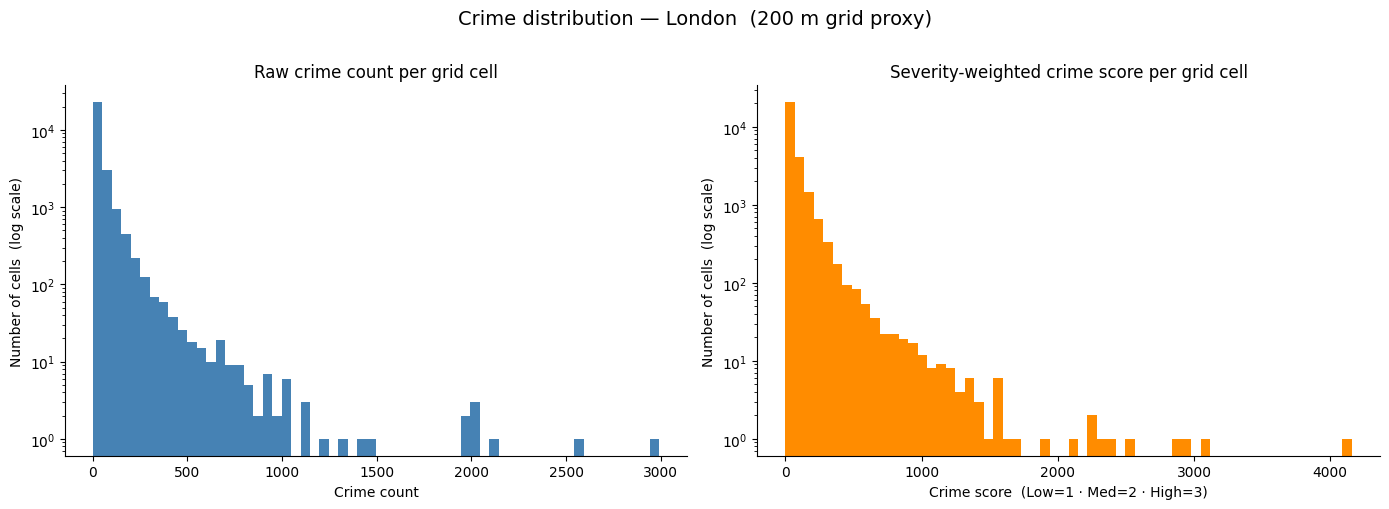


Raw count  —  equal-width thresholds: 998.0 / 1995.0
  Safe    : 27,880 cells  (99.9%)
  Neutral : 15 cells  (0.1%)
  Unsafe  : 6 cells  (0.0%)

Weighted score  —  equal-width thresholds: 1386.7 / 2772.3
  Safe    : 27,878 cells  (99.9%)
  Neutral : 19 cells  (0.1%)
  Unsafe  : 4 cells  (0.0%)


In [ ]:
crimes_m['gx'] = (crimes_m['x'] // GRID_M).astype(int)
crimes_m['gy'] = (crimes_m['y'] // GRID_M).astype(int)

raw_counts = crimes_m.groupby(['gx', 'gy']).size().rename('crime_count')
wgt_scores = crimes_m.groupby(['gx', 'gy'])['weight'].sum().rename('crime_score')
grid = pd.concat([raw_counts, wgt_scores], axis=1).reset_index()

print(f'Grid cells with at least 1 crime : {len(grid):,}')
print(f'Max raw count in a cell          : {grid["crime_count"].max()}')
print(f'Max weighted score in a cell     : {grid["crime_score"].max()}')
print(f'Median raw count                 : {grid["crime_count"].median():.1f}')
print(f'Median weighted score            : {grid["crime_score"].median():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(grid['crime_count'], bins=60, color='steelblue', edgecolor='none', log=True)
axes[0].set_title('Raw crime count per grid cell', fontsize=12)
axes[0].set_xlabel('Crime count')
axes[0].set_ylabel('Number of cells  (log scale)')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(grid['crime_score'], bins=60, color='darkorange', edgecolor='none', log=True)
axes[1].set_title('Severity-weighted crime score per grid cell', fontsize=12)
axes[1].set_xlabel('Crime score  (Low=1 · Med=2 · High=3)')
axes[1].set_ylabel('Number of cells  (log scale)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Crime distribution — London  (200 m grid proxy)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
for col, label in [('crime_count', 'Raw count'), ('crime_score', 'Weighted score')]:
    mn, mx = grid[col].min(), grid[col].max()
    t1, t2 = mn + (mx - mn) / 3, mn + 2 * (mx - mn) / 3
    safe_n    = (grid[col] <= t1).sum()
    neutral_n = ((grid[col] > t1) & (grid[col] <= t2)).sum()
    unsafe_n  = (grid[col] > t2).sum()
    print(f'\n{label}  —  equal-width thresholds: {t1:.1f} / {t2:.1f}')
    print(f'  Safe    : {safe_n:,} cells  ({100*safe_n/len(grid):.1f}%)')
    print(f'  Neutral : {neutral_n:,} cells  ({100*neutral_n/len(grid):.1f}%)')
    print(f'  Unsafe  : {unsafe_n:,} cells  ({100*unsafe_n/len(grid):.1f}%)')


Raw count  —  equal-width thresholds: 998.0 / 1995.0
  Safe    : 27,880 cells  (99.9%)
  Neutral : 15 cells  (0.1%)
  Unsafe  : 6 cells  (0.0%)

Weighted score  —  equal-width thresholds: 1386.7 / 2772.3
  Safe    : 27,878 cells  (99.9%)
  Neutral : 19 cells  (0.1%)
  Unsafe  : 4 cells  (0.0%)
